In [52]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [54]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image.to(device)

content = load_image("content.jpg")
style = load_image("style.jpg")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

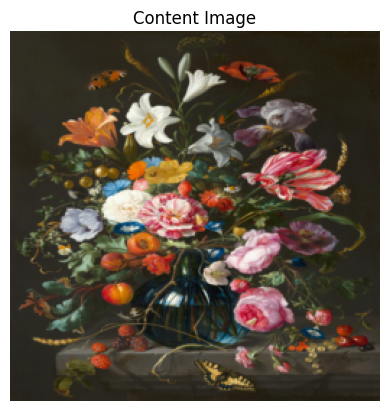

In [55]:
plt.imshow(content.cpu().squeeze().permute(1,2,0))
plt.title("Content Image")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

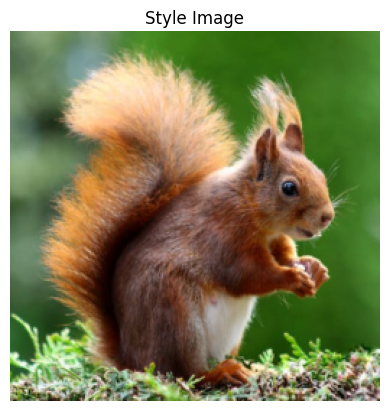

In [56]:
plt.imshow(style.cpu().squeeze().permute(1,2,0))
plt.title("Style Image")
plt.axis("off")

In [57]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [58]:
target = content.clone().requires_grad_(True).to(device)

In [59]:
optimizer = torch.optim.Adam([target], lr=0.01)

In [60]:
for step in range(300):

    target_features = vgg(target)
    content_features = vgg(content)
    style_features = vgg(style)

    content_loss = torch.mean((target_features - content_features)**2)
    style_loss = torch.mean((target_features - style_features)**2)

    loss = content_loss + 1000 * style_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print("Step:", step, "Loss:", loss.item())

Step: 0 Loss: 1091.353759765625
Step: 50 Loss: 104.41059875488281
Step: 100 Loss: 39.84096145629883
Step: 150 Loss: 25.737539291381836
Step: 200 Loss: 20.388816833496094
Step: 250 Loss: 15.258105278015137


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

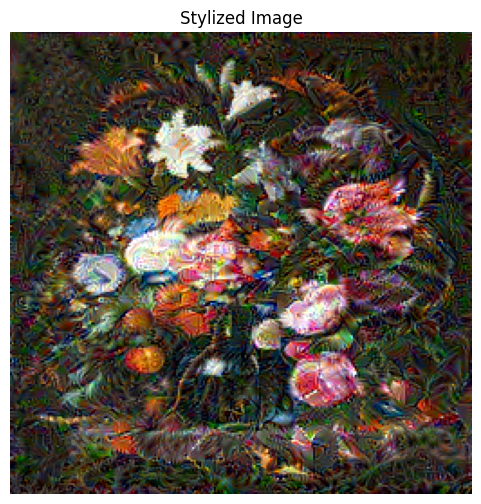

In [61]:
result = target.cpu().detach().squeeze().permute(1,2,0)

plt.figure(figsize=(6,6))
plt.imshow(result)
plt.title("Stylized Image")
plt.axis("off")